# Test Analysis

### TLDR
This notebook performs the final evaluation of the model using the test dataset.

### Objective
Evaluate the model's generalization capabilities on unseen data.

### Description
* **Data Loading**: Loads the test dataset and a trained checkpoint.
* **Metrics Calculation**: Calculates performance metrics: Confusion Matrix, Accuracy, Precision, Recall, and F1-score.
* **Error Analysis**: Visualizes the confusion matrix for class-wise error analysis.
* **Macro Comparison**: Displays macro metrics in a bar chart for quick comparison.

### Results
* **Confusion Matrix**: Visualization of the confusion matrix.
* **Performance Summary**: Bar chart summary of macro metrics.


In [1]:

# no teste vai ser diferente, vamos fazer tudo pelo tester, uma vez que o load_checkpoint não é necessário 
# todas as análises das metricas serão feitas pelo pandas
# e não será necessário variáveis globais
# e vai ter curva roc e auc


In [2]:
# Standard library imports
import sys
import os

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Setting the custom classes
current_dir = os.getcwd() 
utils_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'utils'))
models_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'models'))
notebook_utils = os.path.abspath(os.path.join(current_dir, '..'))

if utils_path not in sys.path: sys.path.append(utils_path)
if models_path not in sys.path: sys.path.append(models_path)
if notebook_utils not in sys.path: sys.path.append(notebook_utils)

print(f"Adicionado ao PATH: {utils_path}")
print(f"Adicionado ao PATH: {models_path}")
print(f"Adicionado ao PATH: {notebook_utils}")

# Local/Project imports
import DatasetsDict as dd
import ModelTester as mt
from StaticMaskTraining import StaticMaskTraining
import NotebookUtils as nu

Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/utils
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/models
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/notebooks


/home/andre-marques/anaconda3/envs/PowerRanger-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#cuda 
torch.set_default_device('cuda')

In [9]:
# 1. 

# Instanciar o Tester (ajuste o device se necessário)
utils = nu.NotebookUtils()
tester = mt.ModelTester("galaxy10", batch=16)

var_global_checkpoint = "vanilla_galaxy10_resnet20"
var_global_epoch = 160
root_dir="../../checkpoints/"


# 2. Executar o Teste
# Note: o seu ModelTester precisa retornar (cm, all_targets, all_probs)
# Se o seu atual só retorna a CM, ajuste o return dele!

cm, accuracy, precision, recall, f1, all_targets, all_probs, all_predictions = tester.test(
        var_global_checkpoint, var_global_epoch
)

print(cm)

Loading train split from Hugging Face (checking download/cache)...
Galaxy10HFDataset: Loaded 15962 images for split 'train'.
Loading test split from Hugging Face (checking download/cache)...
Galaxy10HFDataset: Loaded 1774 images for split 'test'.
[[ 28   3   9   6   0  10   0  48   1   4]
 [  4 133   6   3   0   7   0  27   0   5]
 [  0   1 235   1   0   3   3   7   0   0]
 [  6   3   4 173   2   1   1   7   0   1]
 [  0   0   1   4  19   0   1   0   1   2]
 [  3   4   2   0   1 187   2  14   1   3]
 [  0   0  10   1   0   8 110  49   0   1]
 [  7   2   0   0   0  12  15 235   2   0]
 [  1   1   0   0   2   3   4  11 112  23]
 [  1   0   0   1   1   1   2   0   3 169]]


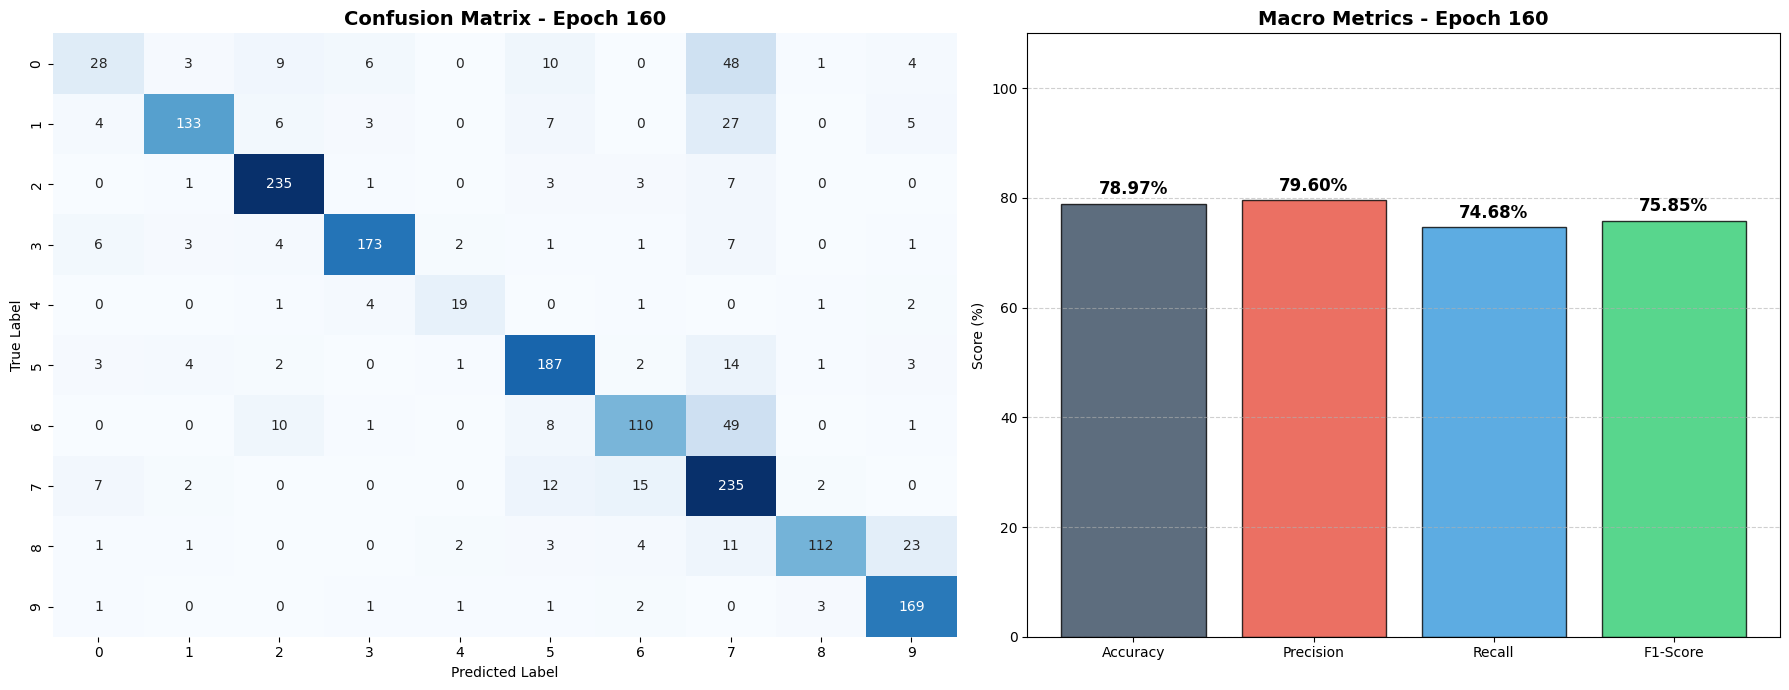

In [10]:
# 2. Setup Figure Layout (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.2, 1]})

# --- LEFT SIDE: Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title(f'Confusion Matrix - Epoch {var_global_epoch}', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# --- RIGHT SIDE: Performance Metrics Bar Chart ---
# Extracting values from the dataframe (using index matching var_global_epoch + 1)
metrics_values_idx = [
    accuracy, precision, recall, f1
]

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#34495e', '#e74c3c', '#3498db', '#2ecc71'] # Elegant colors: Slate, Red, Blue, Green

bars = ax[1].bar(metrics_names, metrics_values_idx, color=colors, alpha=0.8, edgecolor='black')

# Customizing the bar chart
ax[1].set_ylim(0, 110) 
ax[1].set_title(f'Macro Metrics - Epoch {var_global_epoch}', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Score (%)')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

# Adding value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_223561/1648439632.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


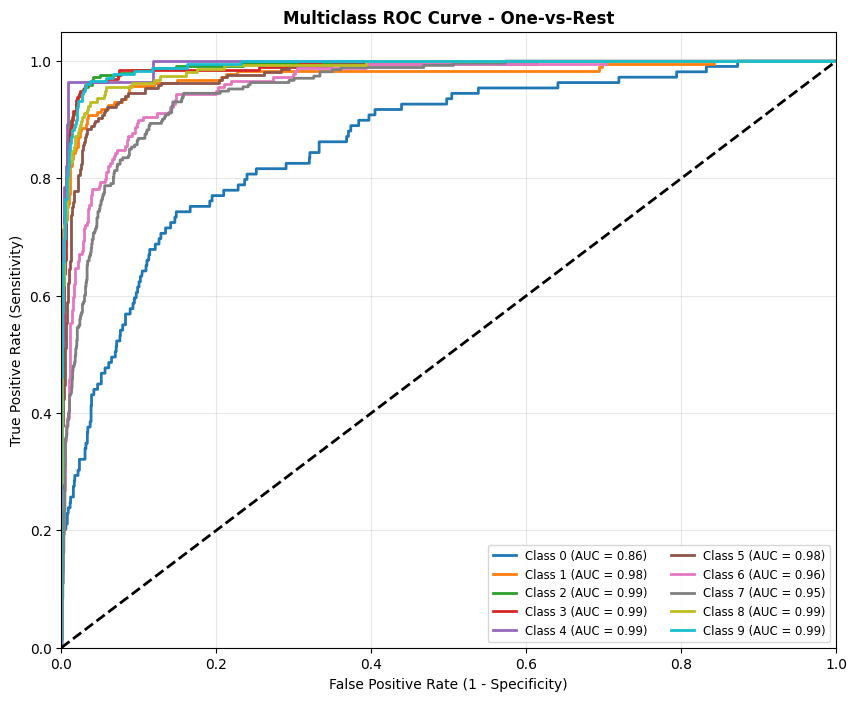

In [11]:

def plot_roc_curve(all_targets, all_probs, n_classes):
    # 1. Binarizar os targets para o formato One-vs-Rest
    y_test = label_binarize(all_targets, classes=np.arange(n_classes))
    y_score = np.array(all_probs)

    # 2. Calcular curvas ROC e AUC para cada classe
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 3. Plotar o gráfico
    plt.figure(figsize=(10, 8))
    
    colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    # Linha de referência (Chute aleatório)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Multiclass ROC Curve - One-vs-Rest', fontweight='bold')
    plt.legend(loc="lower right", fontsize='small', ncol=2)
    plt.grid(alpha=0.3)
    plt.show()

# --- COMO USAR ---
# Supondo que você já rodou: 
# cm, acc, prec, rec, f1, targets, probs, preds = tester.test(...)

plot_roc_curve(all_targets, all_probs, n_classes=cm.shape[0]) # Ajuste n_classes conforme o dataset

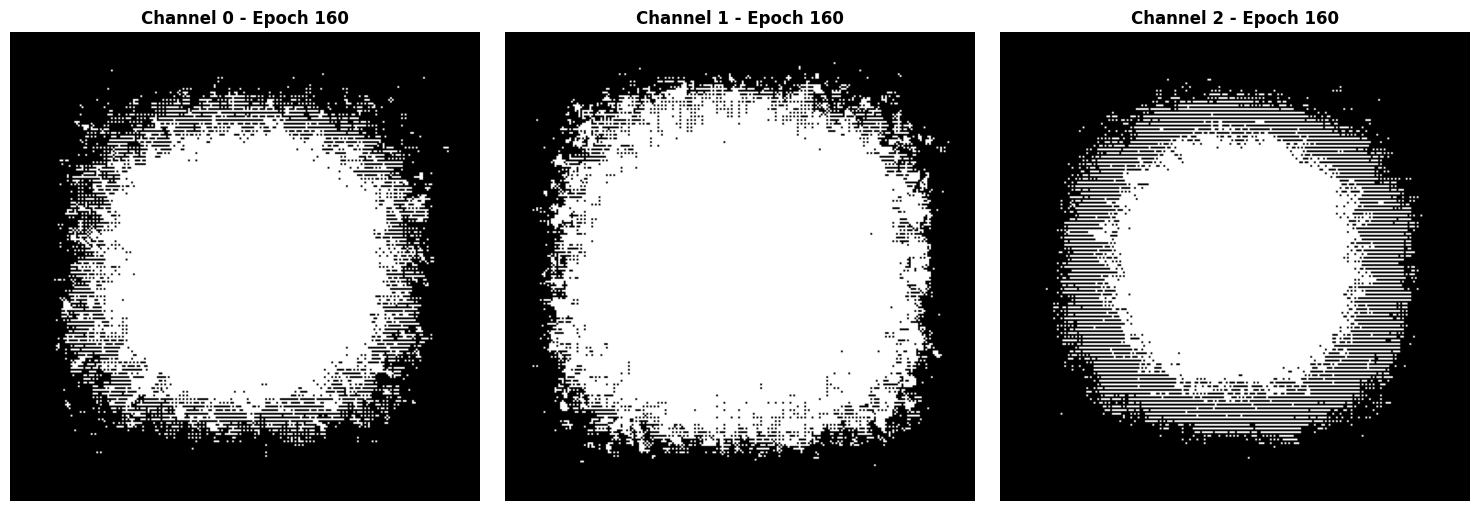

: 

In [ ]:
utils.plot_mask(var_global_checkpoint, var_global_epoch)